Maintenant, nous allons voir les models d'ia pour la prediciton des retards
Nous allons utilisé skilit learn

In [69]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv("cleaned_dataset.csv", sep=",")

# Column sauvegardé
categorical_cols = ["Service", "Departure station", "Arrival station"]

# Nettoyage (optionel si df nettoyé)
for col in df.columns:
    if col in categorical_cols:
        continue
    if pd.api.types.is_string_dtype(df[col]):
        cleaned = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace(r"\s*min$", "", regex=True)
            .str.replace(r"[^0-9.\-]+", "", regex=True)
        )
        df[col] = pd.to_numeric(cleaned, errors="coerce")

# Cible
target = "Average delay of all trains at arrival"

drop_cols = [
    "Date", "Cancellation comments", "Departure delay comments",
    "Arrival delay comments", "Number of trains delayed > 15min",
    "Average delay of trains > 15min (if competing with flights)",
    "Number of trains delayed > 30min", "Number of trains delayed > 60min",
    target
]

X = df.drop(columns=drop_cols)
y = pd.to_numeric(df[target], errors="coerce")

X = pd.get_dummies(X, columns=categorical_cols)

non_numeric_cols = X.select_dtypes(exclude=["number"]).columns
if len(non_numeric_cols) > 0:
    X = X.drop(columns=non_numeric_cols)

# Supprimer les colonnes 100% manquantes
all_nan_cols = [col for col in X.columns if X[col].notna().sum() == 0]
if all_nan_cols:
    X = X.drop(columns=all_nan_cols)

# Supprimer les lignes avec valeurs manquantes
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

Notre IA doit donc s'entrainer et tester. Il lui definie donc des paramètres pour savoir sur combien de pourcents du csv il s'entrainera. Ici on lui definie 0.2 correspondant a 20 % du csv

In [70]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


On definie donc le model de l'ia et son entrainement ici un model Linear Regression


In [71]:
# Modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 1.67
MSE  : 10.35
R²   : 0.4397


On obtient donc 3 resultats du model 

MAE : mean absolute error il se trompe donc de 1,64 min en moyenne
MSE : mean squared error, la plus haute erreur dans les pires cas
R² : de 0 a 1, determine si le model est pertinent au plus proche de 1, ici il l'est moyennement


On test un autre model, le randomForestRegressor

In [72]:
# Modèle
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 1.25
MSE  : 7.85
R²   : 0.5750


On obtient de plus nette performance car les erreur de retard son tres peut lineaire d'ou les performances accrues du random forest

In [73]:
# Modèle
model = MLPRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 1.78
MSE  : 10.78
R²   : 0.4165


In [74]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE : 1.94
MSE  : 14.75
R²   : 0.2014


In [75]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Evaluation

y_pred = model.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


MAE : 1.35
MSE  : 8.12
R²   : 0.5605


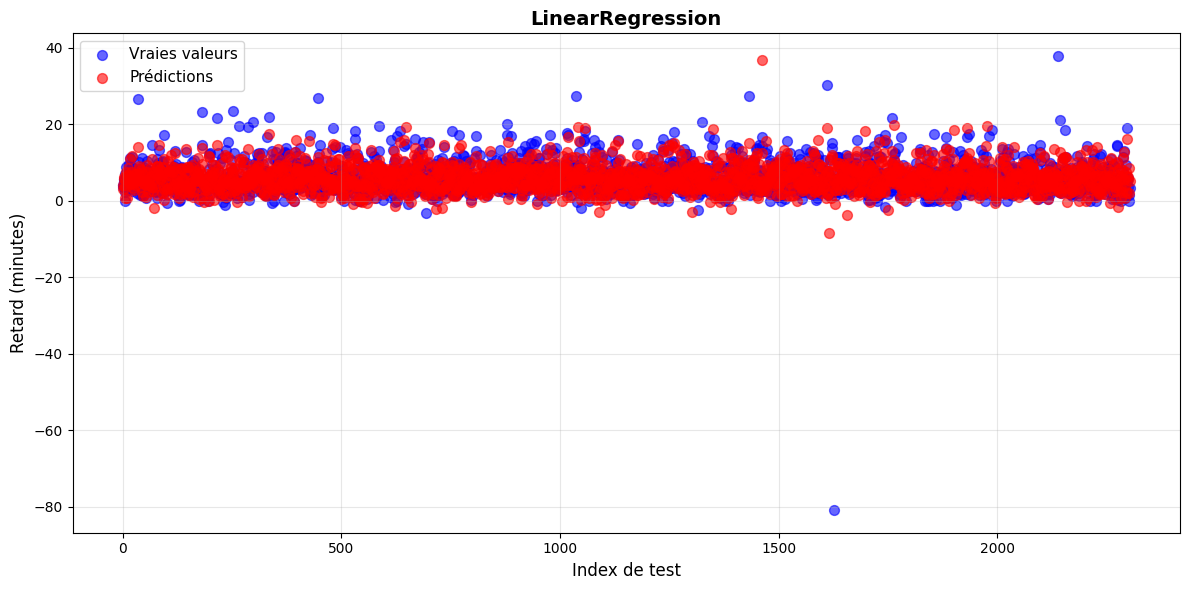

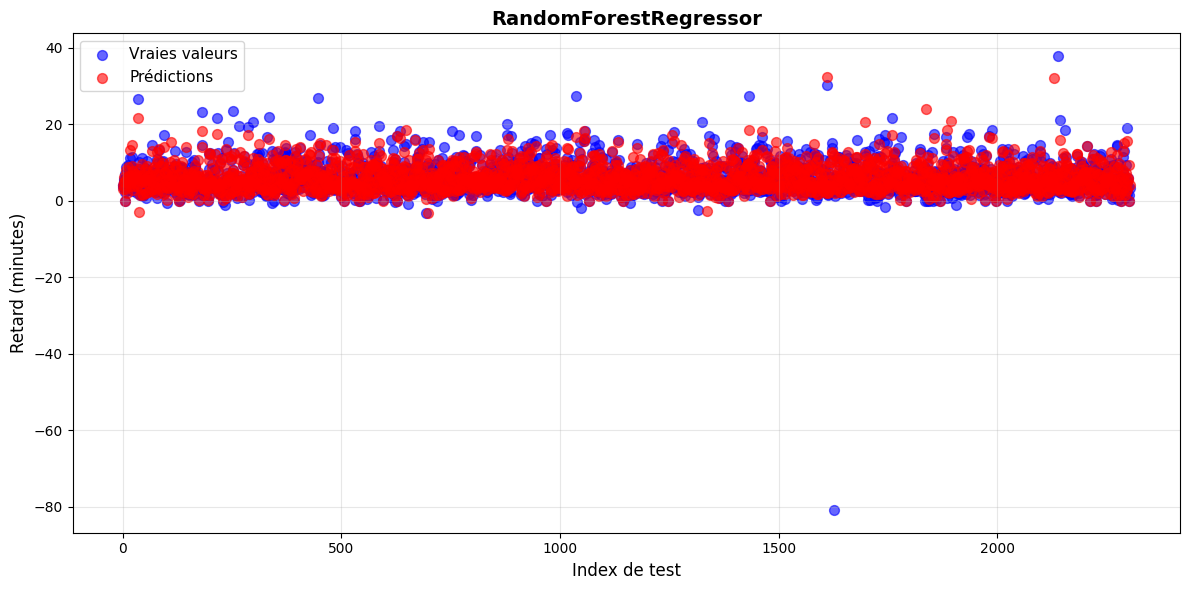

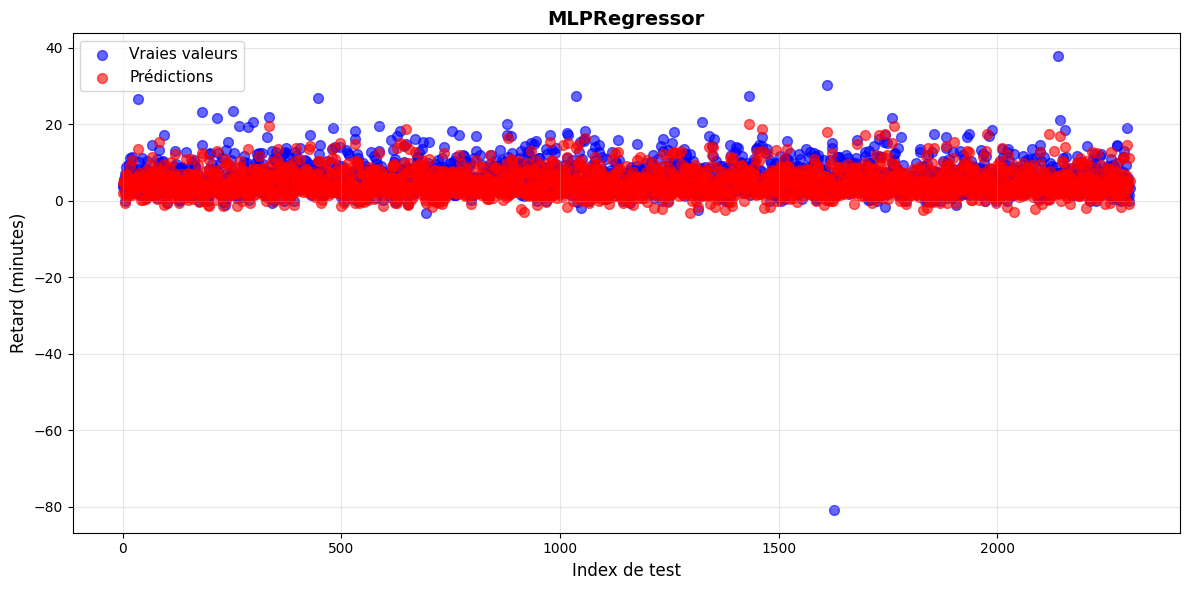

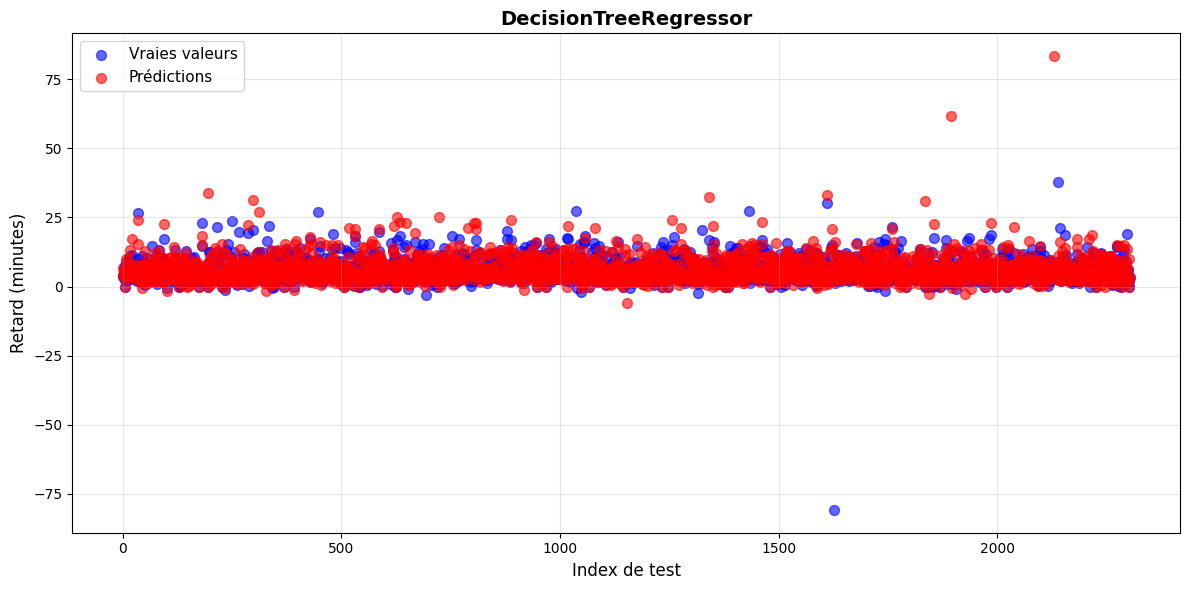

In [76]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    ("LinearRegression", LinearRegression()),
    ("RandomForestRegressor", RandomForestRegressor()),
    ("MLPRegressor", MLPRegressor()),
    ("DecisionTreeRegressor", DecisionTreeRegressor())
]

for name, estimator in models:
    # Entraîner le modèle
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    
    # Créer une figure séparée pour chaque modèle
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Graphique: vraies valeurs vs prédictions
    ax.scatter(range(len(y_test)), y_test, label="Vraies valeurs", alpha=0.6, s=50, color="blue")
    ax.scatter(range(len(y_pred)), y_pred, label="Prédictions", alpha=0.6, s=50, color="red")
    
    ax.set_title(f"{name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Index de test", fontsize=12)
    ax.set_ylabel("Retard (minutes)", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [77]:
import xgboost as xgb
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df = pd.read_csv("dataset.csv", sep=";", on_bad_lines="skip")

# Nettoyage
categorical_cols = ["Service", "Departure station", "Arrival station"]

for col in df.columns:
    if col in categorical_cols:
        continue
    if pd.api.types.is_string_dtype(df[col]):
        cleaned = (
            df[col].astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace(r"\s*min$", "", regex=True)
            .str.replace(r"[^0-9.\-]+", "", regex=True)
        )
        df[col] = pd.to_numeric(cleaned, errors="coerce")

# Cible
target = "Average delay of all trains at arrival"

drop_cols = [
    "Date", "Cancellation comments", "Departure delay comments",
    "Arrival delay comments", "Number of trains delayed > 15min",
    "Average delay of trains > 15min (if competing with flights)",
    "Number of trains delayed > 30min", "Number of trains delayed > 60min",
    target
]

X = df.drop(columns=drop_cols)
y = pd.to_numeric(df[target], errors="coerce")

X = pd.get_dummies(X, columns=categorical_cols)

non_numeric_cols = X.select_dtypes(exclude=["number"]).columns
if len(non_numeric_cols) > 0:
    X = X.drop(columns=non_numeric_cols)

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle XGBoost
model = xgb.XGBRegressor(
    n_estimators=5000,    # nombre d'arbres
    max_depth=6,         # profondeur max de chaque arbre
    learning_rate=0.001,   # vitesse d'apprentissage
    random_state=42
)

# Entraînement
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# Sauvegarde
joblib.dump(model, "model.pkl")
print("Modèle sauvegardé dans model.pkl")

# Recharger et réutiliser
model = joblib.load("model.pkl")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

model = joblib.load("model.pkl")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

RMSE : 2.81
MAE  : 1.15
R²   : 0.7887
Modèle sauvegardé dans model.pkl
RMSE : 2.81
MAE  : 1.15
R²   : 0.7887
RMSE : 3.91
MAE  : 1.23
R²   : 0.5208
